# Phase 3: Recommendation System

In this notebook, you will:
1. Build a content-based filtering system using property features
2. Implement collaborative filtering (user-based and item-based)
3. Create a hybrid recommendation system
4. Evaluate recommendation quality

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')
from src.data_loader import load_housing_data, preprocess_features
from src.recommendation import *

## 1. Data Preparation

In [2]:
df = load_housing_data()
X_scaled, y, feature_names, scaler = preprocess_features(df)
print(f"Properties: {X_scaled.shape[0]}, Features: {X_scaled.shape[1]}")

Properties: 20640, Features: 8


## 2. Content-Based Filtering

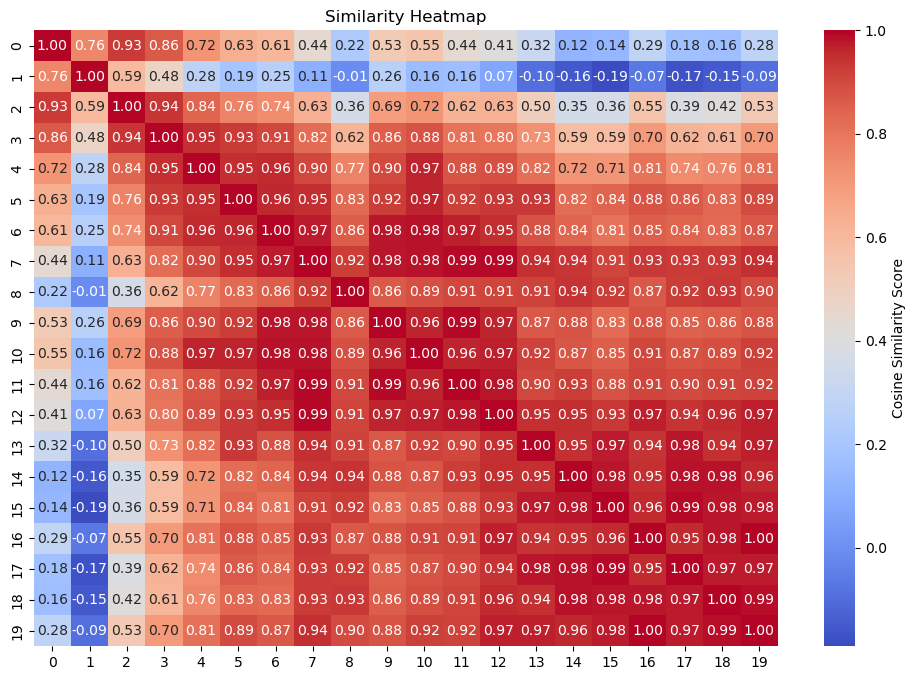

In [3]:
# TODO: Compute similarity matrix
# TODO: Get recommendations for a sample property
# TODO: Visualize similarity heatmap (use a subset)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

X = df.select_dtypes(include=['number'])

# If not scaled already
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
similarity_matrix = cosine_similarity(X_scaled)
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=df.index,
    columns=df.index
)
subset_size = 20
subset_sim = similarity_df.iloc[:subset_size, :subset_size]

plt.figure(figsize=(12, 8))
sns.heatmap(
    subset_sim,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={'label': 'Cosine Similarity Score'}
)
plt.title("Similarity Heatmap")
plt.show()

In [4]:
# TODO: Use KNN-based recommendations
# Compare with cosine similarity recommendations
# Fit KNN model
def get_cosine_recommendations(similarity_df, item_index, top_n=5):
    # Get similarity scores for the given item
    sim_scores = similarity_df.iloc[item_index]

    # Sort descending (excluding itself)
    sim_scores = sim_scores.sort_values(ascending=False)

    # Skip first one (it's the same item)
    top_items = sim_scores.iloc[1:top_n+1]

    return top_items
knn_model = NearestNeighbors(metric='euclidean', algorithm='auto')
knn_model.fit(X_scaled)

def get_knn_recommendations(knn_model, X_scaled, item_index, top_n=5):
    distances, indices = knn_model.kneighbors(
        [X_scaled[item_index]], 
        n_neighbors=top_n+1
    )

    # Remove the item itself (first index)
    indices = indices.flatten()[1:]
    distances = distances.flatten()[1:]

    return indices, distances



In [5]:
test_idx = 0
n = 5

print(f"--- Comparison for Property at Index {test_idx} ---")

# --- Cosine Results ---
cos_results = get_cosine_recommendations(similarity_df, test_idx, top_n=n)
print(f"\nCosine Similarity Top {n} Indices:")
print(cos_results.index.tolist())

# --- KNN Results ---
knn_indices, knn_dists = get_knn_recommendations(knn_model, X_scaled, test_idx, top_n=n)
print(f"\nKNN Euclidean Top {n} Indices:")
print(knn_indices.tolist())

# --- Analysis ---
# Check if the two methods agreed on any properties
common = set(cos_results.index.tolist()).intersection(set(knn_indices.tolist()))
print(f"\nProperties suggested by BOTH methods: {list(common)}")

--- Comparison for Property at Index 0 ---

Cosine Similarity Top 5 Indices:
[9356, 17611, 1635, 17159, 1632]

KNN Euclidean Top 5 Indices:
[17159, 9398, 18321, 1570, 9401]

Properties suggested by BOTH methods: [17159]


In [6]:
df['user_id'] = np.random.randint(1, 50, size=len(df))  # 50 users
df['interaction'] = 1  # binary interaction (viewed/liked)

## 3. Collaborative Filtering

In [7]:
user_property_matrix = df.pivot_table(
    index='user_id',
    columns=df.index,   # each row = property
    values='interaction',
    fill_value=0
)

In [8]:
# TODO: Create user-property interaction matrix
# Visualize sparsity pattern
import matplotlib.pyplot as plt

def visualize_sparsity(matrix):
    if hasattr(matrix, "values"):
        matrix = matrix.values

    plt.figure(figsize=(10, 6))
    plt.spy(matrix, markersize=1, aspect='auto')

    plt.title("User-Property Interaction Sparsity Pattern")
    plt.xlabel("Property ID")
    plt.ylabel("User ID")
    plt.show()

    total_cells = matrix.size
    non_zero = np.count_nonzero(matrix)
    sparsity = (1 - (non_zero / total_cells)) * 100

    print(f"Total Cells: {total_cells}")
    print(f"Non-zero Interactions: {non_zero}")
    print(f"Matrix Sparsity: {sparsity:.2f}%")


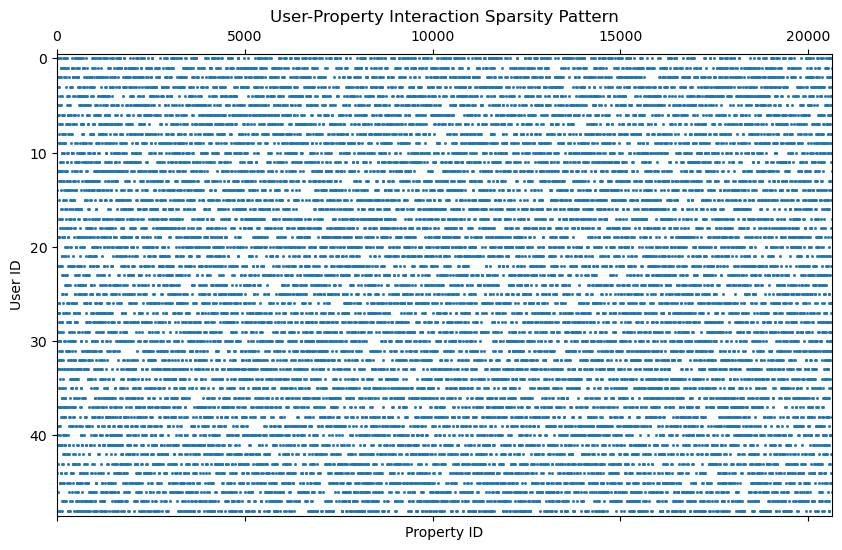

Total Cells: 1011360
Non-zero Interactions: 20640
Matrix Sparsity: 97.96%
(49, 20640)


In [9]:
visualize_sparsity(user_property_matrix)
print(user_property_matrix.shape)


In [10]:
# TODO: User-based collaborative filtering
# Get recommendations for sample users
user_similarity = cosine_similarity(user_property_matrix)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_property_matrix.index,
    columns=user_property_matrix.index
)

In [11]:
user_property_matrix = create_user_property_matrix(
    n_users=100,
    n_properties=500,
    sparsity=0.95,
    random_state=42
)

recommendations = user_based_collaborative_filter(
    user_property_matrix,
    user_index=0,
    n_recommendations=5
)

recommendations

[{'property_index': 308, 'predicted_rating': 1.0819834089569842},
 {'property_index': 332, 'predicted_rating': 1.0226544831930289},
 {'property_index': 393, 'predicted_rating': 0.8938095431912579},
 {'property_index': 396, 'predicted_rating': 0.8637041150526594},
 {'property_index': 271, 'predicted_rating': 0.8504538973266746}]

In [12]:
# TODO: Item-based collaborative filtering
# Compare with user-based results

user_property_matrix = create_user_property_matrix(
    n_users=100,
    n_properties=500,
    sparsity=0.95,
    random_state=42
)

sample_user = 0

user_based_results = user_based_collaborative_filter(
    user_property_matrix,
    user_index=sample_user,
    n_recommendations=5
)

item_based_results = item_based_collaborative_filter(
    user_property_matrix,
    user_index=sample_user,
    n_recommendations=5
)

print("User-Based Recommendations:")
for rec in user_based_results:
    print(rec)

print("\nItem-Based Recommendations:")
for rec in item_based_results:
    print(rec)

User-Based Recommendations:
{'property_index': 308, 'predicted_rating': 1.0819834089569842}
{'property_index': 332, 'predicted_rating': 1.0226544831930289}
{'property_index': 393, 'predicted_rating': 0.8938095431912579}
{'property_index': 396, 'predicted_rating': 0.8637041150526594}
{'property_index': 271, 'predicted_rating': 0.8504538973266746}

Item-Based Recommendations:
{'property_index': 0, 'predicted_rating': 3.808473975541715}


## 4. Hybrid Recommendation System

In [13]:
user_property_matrix = create_user_property_matrix(
    n_users=100,
    n_properties=X_scaled.shape[0],
    sparsity=0.95,
    random_state=42
)

In [14]:
# TODO: Build hybrid recommender
# Experiment with different content_weight / collaborative_weight

sample_user = 0
sample_property = 10

for content_w, collab_w in [(0.8, 0.2), (0.5, 0.5), (0.2, 0.8)]:
    print(f"\nContent Weight: {content_w}, Collaborative Weight: {collab_w}")

    hybrid_results = hybrid_recommend(
        property_features=X_scaled,
        user_property_matrix=user_property_matrix,
        user_index=sample_user,
        property_index=sample_property,
        content_weight=content_w,
        collaborative_weight=collab_w,
        n_recommendations=5
    )

    for rec in hybrid_results:
        print(rec)


Content Weight: 0.8, Collaborative Weight: 0.2
{'property_index': 393, 'content_score': 0.9748111268318831, 'collaborative_score': 0.4093068074481043, 'hybrid_score': 0.8617102629551274}
{'property_index': 15807, 'content_score': 0.9770505496894427, 'collaborative_score': 0.2805628773050683, 'hybrid_score': 0.8377530152125678}
{'property_index': 15858, 'content_score': 0.9444039068002473, 'collaborative_score': 0.2671363412479546, 'hybrid_score': 0.8089503936897888}
{'property_index': 565, 'content_score': 0.996775241509057, 'collaborative_score': 0.0, 'hybrid_score': 0.7974201932072457}
{'property_index': 16027, 'content_score': 0.9965342818772629, 'collaborative_score': 0.0, 'hybrid_score': 0.7972274255018104}

Content Weight: 0.5, Collaborative Weight: 0.5
{'property_index': 393, 'content_score': 0.9748111268318831, 'collaborative_score': 0.4093068074481043, 'hybrid_score': 0.6920589671399937}
{'property_index': 18867, 'content_score': 0.8683678089624272, 'collaborative_score': 0.5

## 5. Evaluation

In [15]:
# TODO: Evaluate each recommendation approach
# Compare precision/recall across methods

sample_user = 0

user_ratings = user_property_matrix[sample_user]

ground_truth = {
    idx: rating
    for idx, rating in enumerate(user_ratings)
    if rating > 0
}

In [16]:
user_based_recs = user_based_collaborative_filter(
    user_property_matrix,
    user_index=sample_user,
    n_recommendations=5
)

item_based_recs = item_based_collaborative_filter(
    user_property_matrix,
    user_index=sample_user,
    n_recommendations=5
)

hybrid_recs = hybrid_recommend(
    property_features=X_scaled,
    user_property_matrix=user_property_matrix,
    user_index=sample_user,
    property_index=10,
    content_weight=0.5,
    collaborative_weight=0.5,
    n_recommendations=5
)

In [17]:
user_eval = evaluate_recommendations(user_based_recs, ground_truth)
item_eval = evaluate_recommendations(item_based_recs, ground_truth)
hybrid_eval = evaluate_recommendations(hybrid_recs, ground_truth)

print("User-Based:", user_eval)
print("Item-Based:", item_eval)
print("Hybrid:", hybrid_eval)

User-Based: {'precision': 0.0, 'recall': 0.0, 'n_relevant_recommended': 0, 'n_recommended': 5, 'n_relevant_total': 415}
Item-Based: {'precision': 0.0, 'recall': 0.0, 'n_relevant_recommended': 0, 'n_recommended': 1, 'n_relevant_total': 415}
Hybrid: {'precision': 0.0, 'recall': 0.0, 'n_relevant_recommended': 0, 'n_recommended': 5, 'n_relevant_total': 415}


In [18]:
comparison = pd.DataFrame([
    {"Method": "User-Based", **user_eval},
    {"Method": "Item-Based", **item_eval},
    {"Method": "Hybrid", **hybrid_eval}
])

print(comparison)

       Method  precision  recall  n_relevant_recommended  n_recommended  \
0  User-Based        0.0     0.0                       0              5   
1  Item-Based        0.0     0.0                       0              1   
2      Hybrid        0.0     0.0                       0              5   

   n_relevant_total  
0               415  
1               415  
2               415  


## Summary

TODO: Write a summary:
- Which approach produced the most relevant recommendations?
- How did the hybrid system compare to individual approaches?
- What are the limitations of each method for real estate?